# Restatement Alone vs Scaffolding Effect

Does prompt length change the variance of LLM numeric answers -- or is it something more specific?

iter-1 of this project found that a confounded "relevant elaboration" prompt condition (redundant restatement of a GSM8K question *plus* generic verification-scaffolding language, e.g. unit-consistency reminders) raised the variance/CV of an LLM's numeric answer relative to length-matched irrelevant filler text. That condition bundles two possible mechanisms together: (1) redundant **restatement** of the problem, and (2) generic verification **scaffolding** language.

This experiment decomposes the two mechanisms by sampling four conditions side by side for the same 8 GSM8K seed problems, across 3 OpenAI-hosted models (`gpt-4o-mini`, `gpt-4.1-mini`, `gpt-4.1-nano`), 15 samples each at temperature 0.7:

| condition | length tier | content |
|---|---|---|
| `control` | 0 | bare question, no added text |
| `filler` | 2 | irrelevant padding, length-matched to tier 2 |
| `paraphrase_only` | 2 | the question restated redundantly, **no** scaffolding language |
| `paraphrase_scaffold` | 2 | the same restatement **plus** generic verification scaffolding |

For every completion the script extracts a numeric answer via a regex cascade and computes two entropy proxies from the OpenRouter logprobs (mean Shannon entropy of the top-5 token distribution over the first 20 generated tokens, and at the located answer token). Per-(prompt, model) cells are then aggregated to `answer_cv` (coefficient of variation), `answer_variance`, `frac_correct`, and mean entropy -- exactly the ported-verbatim pipeline from iter-1, so results are directly comparable.

The key comparison: a **restatement effect** shows up as `paraphrase_only` CV > `filler` CV; a **scaffolding effect** (on top of restatement) shows up as `paraphrase_scaffold` CV > `paraphrase_only` CV.

This notebook reproduces the aggregation and analysis pipeline (`aggregate_results`, `build_summary_stats`, `build_decomposition_comparison` from `method.py`) on a curated subset of the raw completions already collected by the full run -- no live API key is required.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy, pandas, scipy, matplotlib -- pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- original imports from method.py (subset needed for the analysis pipeline) ---
import json
import re

import numpy as np
import pandas as pd
from scipy.stats import entropy as scipy_entropy

import matplotlib.pyplot as plt

## Load the data

The full run made 1440 OpenRouter API calls ($0.33 total) and logged every raw completion to `outputs/raw_completions.jsonl`. Rather than replaying those live API calls (which would need an `OPENROUTER_API_KEY` and re-spend budget), this notebook loads a curated subset of those already-collected raw completions -- one prompt per condition (`control`/`filler`/`paraphrase_only`/`paraphrase_scaffold`), each of the 3 models, up to 8 samples per cell (96 raw completion records) -- and reruns the exact aggregation/analysis code from `method.py` on it.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-0e9809-interpretive-load-not-token-count-drives/main/round-2/experiment-1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
raw_rows = data["examples"]
print(f"Loaded {len(raw_rows)} raw completion records")
raw_df = pd.DataFrame(raw_rows)
raw_df.head()

Loaded 96 raw completion records


,prompt_id,model,sample_idx,content_type,length_tier,token_count,gold_answer,raw_text,answer,mean_entropy_first_k,answer_token_entropy,has_logprobs,cost
0,gsm8k_13__paraphrase_only__t2,openai/gpt-4o-mini,0,paraphrase_only,2,154,18.0,Let's denote the total number of vacuum cleane...,NaN,0.155483,NaN,True,0.000264
1,gsm8k_13__paraphrase_only__t2,openai/gpt-4o-mini,1,paraphrase_only,2,154,18.0,Let's denote the number of vacuum cleaners Mel...,NaN,0.148928,NaN,True,0.000264
2,gsm8k_13__paraphrase_only__t2,openai/gpt-4o-mini,2,paraphrase_only,2,154,18.0,Let \( x \) be the number of vacuum cleaners M...,NaN,0.154186,NaN,True,0.000264
3,gsm8k_13__paraphrase_only__t2,openai/gpt-4o-mini,3,paraphrase_only,2,154,18.0,Let's denote the number of vacuum cleaners Mel...,18.0,0.148928,4.618857e-07,True,0.000264
4,gsm8k_13__paraphrase_only__t2,openai/gpt-4o-mini,4,paraphrase_only,2,154,18.0,Let \( x \) be the number of vacuum cleaners M...,NaN,0.160399,NaN,True,0.000264


## Config

The original `method.py` config governs *sampling* (which we skip here, since we're working from already-collected completions) and the two thresholds used by the aggregation step: the minimum number of valid samples needed to compute a variance/CV at all, and the "low n" flag threshold used to caveat cells with few valid samples. This demo's `mini_demo_data.json` has up to 8 samples per (prompt, model) cell (vs. the full run's 15), so `MIN_VALID_FOR_STATS` is left at the original value -- it is a statistical threshold, not a runtime knob.

In [5]:
# --- config (subset of method.py's constants relevant to the aggregation step) ---
MIN_VALID_FOR_STATS = 2   # need >=2 valid answers to compute sd/variance/cv (method.py: aggregate_results)
LOW_N_THRESHOLD = 5       # cells with fewer valid samples than this get low_n_flag=True
MODELS = ["openai/gpt-4o-mini", "openai/gpt-4.1-mini", "openai/gpt-4.1-nano"]

## Aggregate raw completions to per-(prompt, model) cells

This is `aggregate_results` from `method.py`, copied as-is. For each (prompt_id, model) group it computes the mean/sd/variance/CV of the extracted numeric answers, `frac_correct` against the gold answer, and the mean of the two entropy proxies that were already computed per-completion during the original run (`mean_entropy_first_k`, `answer_token_entropy`).

In [6]:
def aggregate_results(raw_df: pd.DataFrame) -> pd.DataFrame:
    results = []
    for (prompt_id, model), group in raw_df.groupby(["prompt_id", "model"]):
        valid = group.dropna(subset=["answer"])
        n_valid = len(valid)
        answers = valid["answer"].to_numpy(dtype=float)
        gold = group["gold_answer"].iloc[0]
        if n_valid >= MIN_VALID_FOR_STATS:
            answer_mean = float(np.mean(answers))
            answer_sd = float(np.std(answers, ddof=1))
            answer_variance = float(np.var(answers, ddof=1))
            answer_cv = answer_sd / abs(answer_mean) if answer_mean != 0 else float("nan")
            frac_correct = float(np.mean(np.isclose(answers, gold, atol=1e-6)))
        else:
            answer_mean = float(answers[0]) if n_valid == 1 else float("nan")
            answer_sd = float("nan")
            answer_variance = float("nan")
            answer_cv = float("nan")
            frac_correct = float("nan")

        ent_fk = group["mean_entropy_first_k"].dropna()
        ent_ans = group["answer_token_entropy"].dropna()

        results.append(
            {
                "prompt_id": prompt_id,
                "model": model,
                "content_type": group["content_type"].iloc[0],
                "length_tier": int(group["length_tier"].iloc[0]),
                "token_count": int(group["token_count"].iloc[0]),
                "gold_answer": gold,
                "n_samples_attempted": len(group),
                "n_valid_samples": n_valid,
                "pct_unparseable": 1 - n_valid / max(len(group), 1),
                "answer_mean": answer_mean,
                "answer_sd": answer_sd,
                "answer_variance": answer_variance,
                "answer_cv": answer_cv,
                "frac_correct": frac_correct,
                "mean_logprob_entropy_first_k": float(ent_fk.mean()) if len(ent_fk) else None,
                "mean_answer_token_entropy": float(ent_ans.mean()) if len(ent_ans) else None,
                "n_entropy_first_k_obs": int(len(ent_fk)),
                "n_answer_token_entropy_obs": int(len(ent_ans)),
                "low_n_flag": n_valid < LOW_N_THRESHOLD,
            }
        )
    return pd.DataFrame(results)


results_df = aggregate_results(raw_df)
print(f"Aggregated to {len(results_df)} (prompt, model) cells")
results_df

Aggregated to 12 (prompt, model) cells


,prompt_id,model,content_type,length_tier,token_count,gold_answer,n_samples_attempted,n_valid_samples,pct_unparseable,answer_mean,answer_sd,answer_variance,answer_cv,frac_correct,mean_logprob_entropy_first_k,mean_answer_token_entropy,n_entropy_first_k_obs,n_answer_token_entropy_obs,low_n_flag
0,gsm8k_13__control__t0,openai/gpt-4.1-mini,control,0,58,18.0,8,4,0.500,14.250000,7.500000,56.250000,0.526316,0.750000,0.136235,1.421028e-08,8,4,True
1,gsm8k_13__control__t0,openai/gpt-4.1-nano,control,0,58,18.0,8,3,0.625,5.666667,5.507571,30.333333,0.971924,0.000000,0.245089,1.191752e-06,8,3,True
2,gsm8k_13__control__t0,openai/gpt-4o-mini,control,0,58,18.0,8,2,0.750,3.500000,3.535534,12.500000,1.010153,0.000000,0.196748,9.305167e-06,8,2,True
3,gsm8k_13__filler__t2,openai/gpt-4.1-mini,filler,2,309,18.0,8,6,0.250,18.000000,0.000000,0.000000,0.000000,1.000000,0.118250,6.187524e-09,8,6,False
4,gsm8k_13__filler__t2,openai/gpt-4.1-nano,filler,2,309,18.0,8,2,0.750,10.500000,10.606602,112.500000,1.010153,0.500000,0.217502,1.635999e-06,8,2,True
5,gsm8k_13__filler__t2,openai/gpt-4o-mini,filler,2,309,18.0,8,0,1.000,NaN,NaN,NaN,NaN,NaN,0.135496,NaN,8,0,True
6,gsm8k_13__paraphrase_only__t2,openai/gpt-4.1-mini,paraphrase_only,2,154,18.0,8,3,0.625,12.666667,9.237604,85.333333,0.729285,0.666667,0.162871,2.132667e-08,8,3,True
7,gsm8k_13__paraphrase_only__t2,openai/gpt-4.1-nano,paraphrase_only,2,154,18.0,8,3,0.625,10.500000,8.351647,69.750000,0.795395,0.333333,0.193016,8.912939e-03,8,3,True
8,gsm8k_13__paraphrase_only__t2,openai/gpt-4o-mini,paraphrase_only,2,154,18.0,8,2,0.750,10.000000,11.313708,128.000000,1.131371,0.500000,0.172639,4.140496e-06,8,2,True
9,gsm8k_13__paraphrase_scaffold__t2,openai/gpt-4.1-mini,paraphrase_scaffold,2,290,18.0,8,2,0.750,3.500000,2.121320,4.500000,0.606092,0.000000,0.536426,3.536907e-06,8,2,True


## Summary stats

`build_summary_stats` from `method.py`, copied as-is: rolls the per-cell results up to means of CV / entropy / frac_correct broken out by `content_type|length_tier`, plus bookkeeping (call counts, which models returned logprobs, share of low-n cells).

In [7]:
def build_summary_stats(results_df: pd.DataFrame, raw_df: pd.DataFrame, total_cost: float, models: list[str], budget_stopped: bool) -> dict:
    models_with_logprobs = sorted(raw_df.loc[raw_df["has_logprobs"], "model"].unique().tolist())
    models_without_logprobs = sorted(set(models) - set(models_with_logprobs))

    def group_mean(col):
        sub = results_df.dropna(subset=[col])
        if sub.empty:
            return {}
        g = sub.groupby(["content_type", "length_tier"])[col].mean()
        return {f"{a}|{b}": float(v) for (a, b), v in g.items()}

    return {
        "n_prompts": int(results_df["prompt_id"].nunique()),
        "n_models": len(models),
        "models_used": models,
        "n_total_calls_attempted": int(len(raw_df)) if not raw_df.empty else 0,
        "n_total_calls_succeeded": int(raw_df["answer"].notna().sum()) if not raw_df.empty else 0,
        "total_cost_usd": float(total_cost),
        "budget_stopped_early": bool(budget_stopped),
        "mean_cv_by_content_type_length_tier": group_mean("answer_cv"),
        "mean_entropy_first_k_by_content_type_length_tier": group_mean("mean_logprob_entropy_first_k"),
        "mean_answer_token_entropy_by_content_type_length_tier": group_mean("mean_answer_token_entropy"),
        "mean_frac_correct_by_content_type_length_tier": group_mean("frac_correct"),
        "pct_rows_low_n": float(results_df["low_n_flag"].mean()) if len(results_df) else None,
        "pct_rows_missing_logprobs": float(results_df["mean_logprob_entropy_first_k"].isna().mean()) if len(results_df) else None,
        "models_with_logprob_support": models_with_logprobs,
        "models_with_no_logprob_support": models_without_logprobs,
    }


# note: unlike method.py's live-sampling run, this demo has no RunningCost tracker --
# total cost is simply summed from the already-logged per-completion 'cost' field.
summary_stats = build_summary_stats(results_df, raw_df, raw_df["cost"].sum(), MODELS, budget_stopped=False)
print(json.dumps(summary_stats, indent=2))

{
  "n_prompts": 4,
  "n_models": 3,
  "models_used": [
    "openai/gpt-4o-mini",
    "openai/gpt-4.1-mini",
    "openai/gpt-4.1-nano"
  ],
  "n_total_calls_attempted": 96,
  "n_total_calls_succeeded": 31,
  "total_cost_usd": 0.0368444,
  "budget_stopped_early": false,
  "mean_cv_by_content_type_length_tier": {
    "control|0": 0.8361308494176182,
    "filler|2": 0.5050762722761054,
    "paraphrase_only|2": 0.8853501031431702,
    "paraphrase_scaffold|2": 0.3030457633656632
  },
  "mean_entropy_first_k_by_content_type_length_tier": {
    "control|0": 0.19269065551919587,
    "filler|2": 0.15708272458005698,
    "paraphrase_only|2": 0.17617531414851317,
    "paraphrase_scaffold|2": 0.4346482399391613
  },
  "mean_answer_token_entropy_by_content_type_length_tier": {
    "control|0": 3.503709713159474e-06,
    "filler|2": 8.210934797031249e-07,
    "paraphrase_only|2": 0.0029723667767640135,
    "paraphrase_scaffold|2": 5.797853618740275e-06
  },
  "mean_frac_correct_by_content_type_lengt

## The decomposition comparison

`build_decomposition_comparison` from `method.py`, copied as-is -- this is the key comparison the experiment exists to make. It computes mean CV/variance/frac_correct/entropy for each of the 4 conditions, then two differences:

- `restatement_effect_cv` = `paraphrase_only` CV − `filler` CV (positive => pure restatement raises answer instability)
- `scaffolding_effect_cv` = `paraphrase_scaffold` CV − `paraphrase_only` CV (positive => scaffolding on top of restatement raises it further)

In [8]:
def build_decomposition_comparison(results_df: pd.DataFrame) -> dict:
    """The key comparison this experiment exists to make: does variance/CV
    rise from control -> filler -> paraphrase_only -> paraphrase_scaffold?
    A restatement effect shows as filler < paraphrase_only. A scaffolding
    effect (on top of restatement) shows as paraphrase_only < paraphrase_scaffold."""
    out = {}
    for ct, tier in [("control", 0), ("filler", 2), ("paraphrase_only", 2), ("paraphrase_scaffold", 2)]:
        sub = results_df[(results_df["content_type"] == ct) & (results_df["length_tier"] == tier)]
        out[f"{ct}_mean_cv"] = float(sub["answer_cv"].dropna().mean()) if len(sub) and sub["answer_cv"].notna().any() else None
        out[f"{ct}_mean_variance"] = float(sub["answer_variance"].dropna().mean()) if len(sub) and sub["answer_variance"].notna().any() else None
        out[f"{ct}_mean_frac_correct"] = float(sub["frac_correct"].dropna().mean()) if len(sub) and sub["frac_correct"].notna().any() else None
        out[f"{ct}_mean_entropy_first_k"] = float(sub["mean_logprob_entropy_first_k"].dropna().mean()) if len(sub) and sub["mean_logprob_entropy_first_k"].notna().any() else None
        out[f"{ct}_n_prompt_model_cells"] = int(len(sub))

    def diff(a, b):
        if out.get(a) is None or out.get(b) is None:
            return None
        return out[a] - out[b]

    out["restatement_effect_cv"] = diff("paraphrase_only_mean_cv", "filler_mean_cv")
    out["scaffolding_effect_cv"] = diff("paraphrase_scaffold_mean_cv", "paraphrase_only_mean_cv")
    out["restatement_effect_entropy_first_k"] = diff("paraphrase_only_mean_entropy_first_k", "filler_mean_entropy_first_k")
    out["scaffolding_effect_entropy_first_k"] = diff("paraphrase_scaffold_mean_entropy_first_k", "paraphrase_only_mean_entropy_first_k")
    return out


decomposition_comparison = build_decomposition_comparison(results_df)
print(json.dumps(decomposition_comparison, indent=2))

{
  "control_mean_cv": 0.8361308494176182,
  "control_mean_variance": 33.02777777777778,
  "control_mean_frac_correct": 0.25,
  "control_mean_entropy_first_k": 0.19269065551919587,
  "control_n_prompt_model_cells": 3,
  "filler_mean_cv": 0.5050762722761054,
  "filler_mean_variance": 56.25,
  "filler_mean_frac_correct": 0.75,
  "filler_mean_entropy_first_k": 0.15708272458005698,
  "filler_n_prompt_model_cells": 3,
  "paraphrase_only_mean_cv": 0.8853501031431702,
  "paraphrase_only_mean_variance": 94.36111111111113,
  "paraphrase_only_mean_frac_correct": 0.5,
  "paraphrase_only_mean_entropy_first_k": 0.17617531414851317,
  "paraphrase_only_n_prompt_model_cells": 3,
  "paraphrase_scaffold_mean_cv": 0.3030457633656632,
  "paraphrase_scaffold_mean_variance": 2.25,
  "paraphrase_scaffold_mean_frac_correct": 0.0,
  "paraphrase_scaffold_mean_entropy_first_k": 0.4346482399391613,
  "paraphrase_scaffold_n_prompt_model_cells": 3,
  "restatement_effect_cv": 0.3802738308670648,
  "scaffolding_effec

## Results

Mean answer CV (coefficient of variation) by condition, on this notebook's curated subset -- restatement alone vs. restatement + scaffolding, against the control and filler baselines. (Note: with only up to 8 samples per cell instead of the full run's 15, these numbers are for illustration only -- see `full_method_out.json`'s `decomposition_comparison` for the full-scale result.)

condition                mean_cv   mean_frac_correct   n_cells
control                   0.8361              0.2500         3
filler                    0.5051              0.7500         3
paraphrase_only           0.8854              0.5000         3
paraphrase_scaffold       0.3030              0.0000         3

restatement_effect_cv  (paraphrase_only - filler)             = 0.3803
scaffolding_effect_cv  (paraphrase_scaffold - paraphrase_only) = -0.5823


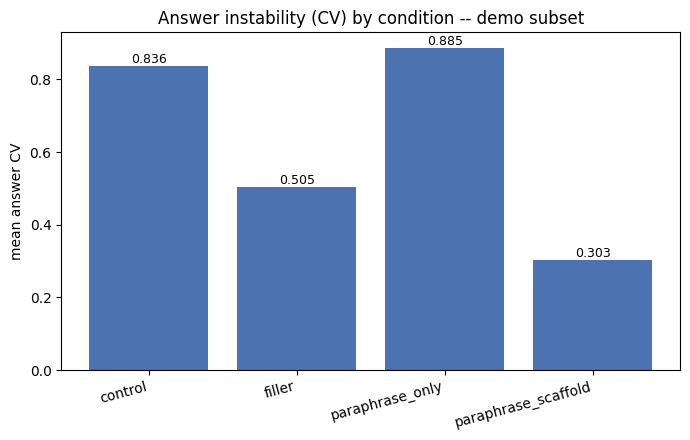

In [9]:
conditions = ["control", "filler", "paraphrase_only", "paraphrase_scaffold"]
cond_cvs = [decomposition_comparison[f"{c}_mean_cv"] for c in conditions]

print(f"{'condition':<22}{'mean_cv':>10}{'mean_frac_correct':>20}{'n_cells':>10}")
for c in conditions:
    cv = decomposition_comparison[f"{c}_mean_cv"]
    fc = decomposition_comparison[f"{c}_mean_frac_correct"]
    n = decomposition_comparison[f"{c}_n_prompt_model_cells"]
    cv_s = f"{cv:.4f}" if cv is not None else "n/a"
    fc_s = f"{fc:.4f}" if fc is not None else "n/a"
    print(f"{c:<22}{cv_s:>10}{fc_s:>20}{n:>10}")

print()
_restatement = decomposition_comparison["restatement_effect_cv"]
_scaffolding = decomposition_comparison["scaffolding_effect_cv"]
_restatement_s = f"{_restatement:.4f}" if _restatement is not None else "n/a (too few valid samples in this demo subset)"
_scaffolding_s = f"{_scaffolding:.4f}" if _scaffolding is not None else "n/a (too few valid samples in this demo subset)"
print(f"restatement_effect_cv  (paraphrase_only - filler)             = {_restatement_s}")
print(f"scaffolding_effect_cv  (paraphrase_scaffold - paraphrase_only) = {_scaffolding_s}")

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ["#888888" if cv is None else "#4C72B0" for cv in cond_cvs]
bars = ax.bar(conditions, [cv if cv is not None else 0 for cv in cond_cvs], color=colors)
ax.set_ylabel("mean answer CV")
ax.set_title("Answer instability (CV) by condition -- demo subset")
ax.set_xticks(range(len(conditions)))
ax.set_xticklabels(conditions, rotation=15, ha="right")
for bar, cv in zip(bars, cond_cvs):
    if cv is not None:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{cv:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()